In [46]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os


import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep', style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

In [2]:
# Let's get organized:
# pickle structure - 
# averagedP_dynamics 

probList = np.linspace(0,1,21).round(2)
rateList1 = [1e-05, 1e-03, 1e-01, 1e+01]
rateList2 = [0.3, 1, 3]
NList=[4, 6, 8, 10]

t_total = 200
dt=5
steps = int(t_total/dt)
rateList = np.logspace(-5,1,4) 

In [3]:
avgedP_dynamics_0 = {}
avgedP_steady_0 = {}

for rate in rateList1:
    
    avgedP_dynamics_0[rate] = {}
    avgedP_steady_0[rate] = {}
    
    for prob in probList:
        
        avgedP_dynamics_0[rate][prob] = {}
        avgedP_steady_0[rate][prob] = {}
                
        with open("RC_avged/avgedP_dynamics_0_p=" + str(prob) + ".pkl", 'rb') as f:
            temp = pickle.load(f)
            
        avgedP_steady_0[rate][prob] = np.zeros(4)

            
        # N=10 dynamics
        avgedP_dynamics_0[rate][prob] = temp[rate][prob][10]
        for (n,N) in enumerate(NList): 
            avgedP_steady_0[rate][prob][n] = np.average(temp[rate][prob][N][steps//2:])
            #print('r=', rate, ' prob=',prob, ' N=', N, 'avg = ', np.average(temp[rate][prob][N][steps//2:]), n)

        

for rate in rateList2:
    
    avgedP_dynamics_0[rate] = {}
    avgedP_steady_0[rate] = {}
    
    for prob in probList:
        
        avgedP_dynamics_0[rate][prob] = {}
        avgedP_steady_0[rate][prob] = {}
                
        with open("RC_avged/avgedP_dynamics_0_extra_rs_p=" + str(prob) + ".pkl", 'rb') as f:
            temp = pickle.load(f)
            
        # N=10 dynamics
        avgedP_dynamics_0[rate][prob] = temp[rate][prob][10]
        
        avgedP_steady_0[rate][prob] = np.zeros(4)
        
        for (n,N) in enumerate(NList): 
            avgedP_steady_0[rate][prob][n] = np.average(temp[rate][prob][N][steps//2:])
            #print('r=', rate, ' prob=',prob, ' N=', N, 'avg = ', np.average(temp[rate][prob][N][steps//2:]), n)
        #print(avgedS_steady_1[rate][prob])

0.9993493627031713
0.9418522478957495
0.12392353550923574
0.06179503745339997
0.05417485320435193
0.05540278459216735
0.06415316263520693


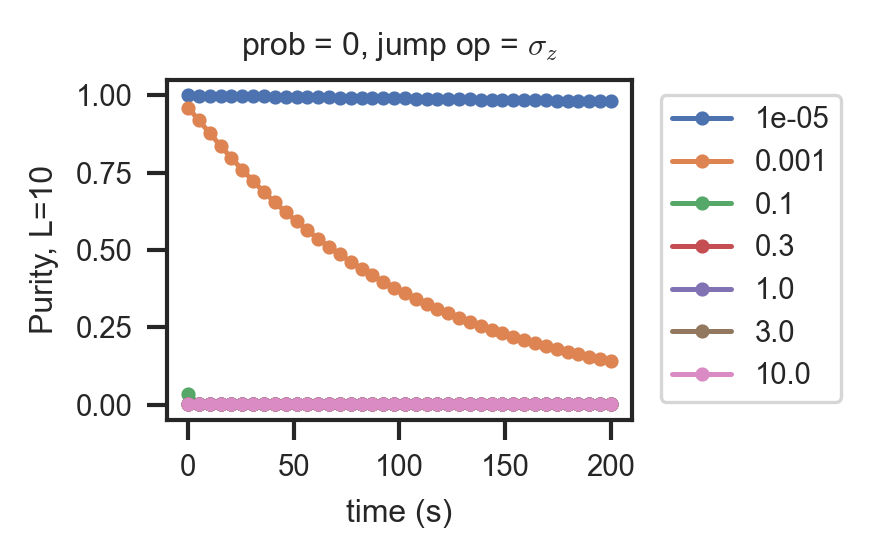

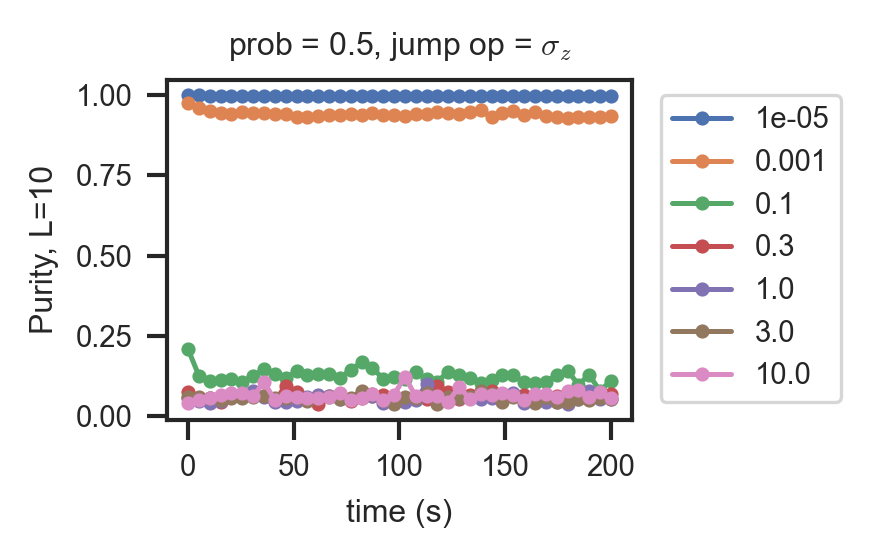

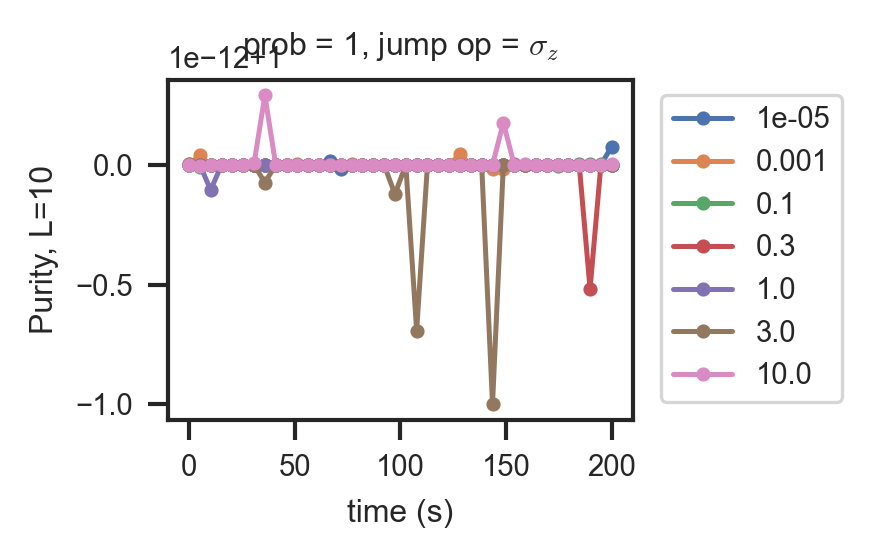

In [6]:
rateList = rateList1 + rateList2
rateList = np.sort(np.array(rateList))

t_total = 200
dt = 5
duration = np.linspace(0,t_total,int(t_total/dt))

plt.figure()
for rates in rateList:
    plt.plot(duration, avgedP_dynamics_0[rates][0.0],'.-')

plt.xlabel('time (s)') 
plt.ylabel('Purity, L=10')
plt.title(r'prob = 0, jump op = $\sigma_z$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )

plt.figure()
for rates in rateList:
    plt.plot(duration, avgedP_dynamics_0[rates][0.5],'.-')
    print(np.average(avgedP_dynamics_0[rates][0.5]))

plt.xlabel('time (s)') 
plt.ylabel('Purity, L=10')
plt.title(r'prob = 0.5, jump op = $\sigma_z$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )



plt.figure()
for rates in rateList:
    plt.plot(duration, avgedP_dynamics_0[rates][1.0],'.-')

plt.xlabel('time (s)') 
plt.ylabel('Purity, L=10')
plt.title(r'prob = 1, jump op = $\sigma_z$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )



In [40]:
# Extract S(L/2) as a function of the dephasing rate at finite probability of msm

probTempList = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1] #np.linspace(0.1, 1, 4)

plt.figure()
for prob in probTempList:
    PinRate = np.zeros(len(rateList))
    for (r,rate) in enumerate(rateList):
        PinRate[r] = np.average(avgedP_dynamics_0[rate][prob][int(t_total/dt)//2:])
        
    plt.semilogx(np.array(rateList), PinRate,'.-')
    plt.xlabel('dephasing rate')
    plt.ylabel('Purity')
plt.title('L = 10 at finite prob of msm')
plt.legend(probTempList, bbox_to_anchor= (1.03, 1) )
print()


KeyError: 1e-05

<Figure size 600x450 with 0 Axes>

In [47]:
rateList3 = ["0.01","0.1","1.0","10.0","100.0","1000.0"]
#rateList = [] #np.logspace(-5,3,9)

probList = np.linspace(0,1,11).round(2)

avgedP_dynamics_0 = {}
avgedP_steady_0 = {}

for rate in rateList3:
    avgedP_dynamics_0[rate] = {}
    avgedP_steady_0[rate] = {}

    for prob in probList: 

        if os.path.isfile("RC_raw/purity_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out"):
            temp = np.array(np.loadtxt("RC_raw/purity_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=10.out") )         
            #print(np.average(temp,axis=0).shape)

            avgedP_dynamics_0[rate][prob] = np.average(temp,axis=0)
            
            avgedP_steady_0[rate][prob] = np.zeros(4)
            
            for (n,N) in enumerate(NList): 
                steps = len(temp)//2

                avgedP_steady_0[rate][prob][n] = np.average(temp[steps:])
        else:
            print('missing rate=',rate,', prob=', prob)

            #"S1_S_minus_p=0.75_r=0.01_N=10.out"



missing rate= 0.01 , prob= 0.0
missing rate= 0.01 , prob= 0.1
missing rate= 0.01 , prob= 0.6
missing rate= 0.01 , prob= 0.7
missing rate= 0.01 , prob= 0.8
missing rate= 0.01 , prob= 0.9
missing rate= 0.01 , prob= 1.0
missing rate= 0.1 , prob= 0.0
missing rate= 0.1 , prob= 0.1
missing rate= 1.0 , prob= 0.0
missing rate= 1.0 , prob= 0.1
missing rate= 10.0 , prob= 0.0
missing rate= 10.0 , prob= 0.1
missing rate= 100.0 , prob= 0.0
missing rate= 100.0 , prob= 0.1
missing rate= 1000.0 , prob= 0.0
missing rate= 1000.0 , prob= 0.1
missing rate= 1000.0 , prob= 0.2


In [51]:
avgedP_dynamics_0

{'0.01': {0.2: array([0.72768112, 0.53041672, 0.39313275, 0.30869202, 0.25258773,
         0.2145973 , 0.18320485, 0.18980356, 0.16388785, 0.15377568,
         0.12948787, 0.12982659, 0.13131567, 0.13171477, 0.13549968,
         0.1314901 , 0.1404629 , 0.1347981 , 0.11631048, 0.11466043,
         0.11761276, 0.10801297, 0.10957624, 0.11332175, 0.109639  ,
         0.1075168 , 0.10401436, 0.10669449, 0.09667146, 0.09175448,
         0.09390266, 0.10574278, 0.1177012 , 0.1022583 , 0.1040037 ,
         0.10897132, 0.11011439, 0.11258007, 0.12369541, 0.1332691 ,
         0.13778553, 0.1382848 , 0.14336367, 0.14426471, 0.14318465,
         0.12709869, 0.12494054, 0.13086375, 0.13476282, 0.13490018,
         0.1346348 , 0.13216251, 0.1440892 , 0.13766103, 0.13860741,
         0.14052934, 0.12709809, 0.12326673, 0.12691833, 0.12125886,
         0.11604661, 0.11151219, 0.11167902, 0.10529594, 0.13207831,
         0.12794055, 0.13498316, 0.12614126, 0.12085724, 0.11286851,
         0.1182121 , 

0.3
0.4
0.5
0.9


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  # Remove the CWD from sys.path while we load stuff.
/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  # Remove the CWD from sys.path while we load stuff.
/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  # Remove the CWD from sys.path while we load stuff.


KeyError: 0.9

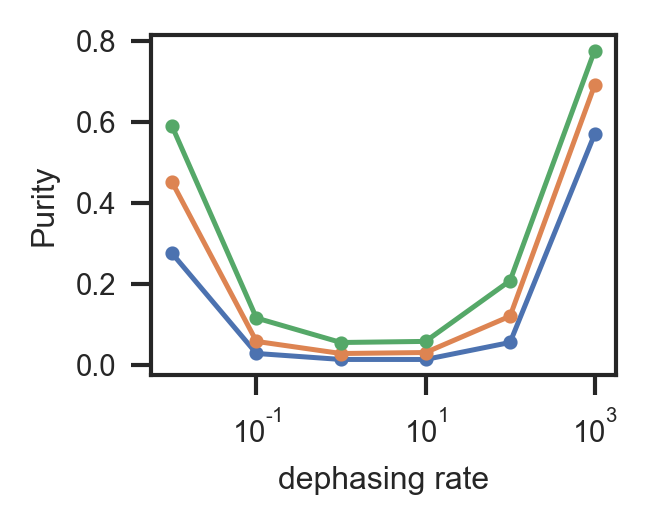

In [49]:
prob = 0.4

probListTemp = [0.3,0.4,0.5,0.9]
plt.figure()

for prob in probListTemp:
    PinRate = np.zeros(len(rateList3))
    print(prob)
    for (r,rate) in enumerate(rateList3):
        if avgedP_dynamics_0[rate][prob]==[]:
            PinRate[r] = 0
        else:
            PinRate[r] = np.average(avgedP_dynamics_0[rate][prob][int(t_total/dt)//2:])

    plt.semilogx(np.array(rateList3).astype(float), PinRate,'.-')
    plt.xlabel('dephasing rate')
    plt.ylabel('Purity')

plt.title('L = 10 at finite prob of msm')
plt.legend(probListTemp, bbox_to_anchor= (1.03, 1) )
print()

In [9]:
# Gates:

Id2 = np.array([[1,0],[0,1]], dtype = 'complex128')
S_X = np.array([[0,1],[1,0]], dtype = 'complex128')
S_Y = np.array([[0,-1j],[1j,0]], dtype = 'complex128')
S_Z = np.array([[1,0],[0,-1]], dtype = 'complex128')

S_plus = (S_X+1j*S_Y)/2
S_minus = (S_X-1j*S_Y)/2

paulis = [Id2, S_X, S_Y, S_Z]/np.sqrt(2)
basis4by4=np.kron(paulis,paulis)

In [11]:
qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')


state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)

S_Z @ state0rho

array([[ 0.5+0.j,  0.5+0.j],
       [-0.5+0.j, -0.5+0.j]])

In [12]:
S_Z @ state0rho @ S_Z.T.conj()

array([[ 0.5+0.j, -0.5+0.j],
       [-0.5+0.j,  0.5+0.j]])

In [13]:
S_Z @ state0rho @ S_Z.T.conj() @ state0rho

array([[-1.23259516e-32+0.j, -1.23259516e-32+0.j],
       [ 1.23259516e-32+0.j,  1.23259516e-32+0.j]])

In [25]:
from functools import reduce
from scipy import linalg
from scipy.stats import unitary_group


Nqubit = 2
rho = reduce(np.kron, [state0rho]*Nqubit)

In [26]:
h = -1j * linalg.logm(unitary_group.rvs(4))

In [28]:
h @ rho - rho @ h

array([[ 1.94289029e-16+0.39087814j,  2.08614157e-01+0.32275103j,
         3.09807132e-01-0.36571304j, -1.14907990e-01+0.43384015j],
       [-2.08614157e-01+0.32275103j,  3.88578059e-16+0.25462392j,
         1.01192975e-01-0.43384015j, -3.23522147e-01+0.36571304j],
       [-3.09807132e-01-0.36571304j, -1.01192975e-01-0.43384015j,
        -2.22044605e-16-1.12230422j, -4.24715122e-01-0.32275103j],
       [ 1.14907990e-01+0.43384015j,  3.23522147e-01+0.36571304j,
         4.24715122e-01-0.32275103j, -3.33066907e-16+0.47680216j]])

In [29]:
0.39087814j+0.25462392j-1.12230422j+0.47680216j

0j